#Part 1

# What is the algorithm?
Decision Tree Regression Algorithm
A machine learning algorithm used to predict continuous numerical values (e.g., house prices or temperatures).
It works by recursively splitting the dataset into smaller subsets in a tree-like structure until it reaches the final prediction.

# How does the algorithm work?

Recursive Binary Splitting
The data is recursively split based on features.
Split Criterion
The algorithm selects the split that minimizes:
Variance: \mathrm{Var}(X)=\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2
MSE: \mathrm{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
Stopping Condition
Splitting stops when a predefined criterion is met (e.g., maximum depth).
Final Prediction
The prediction is the mean value of the target variable in the leaf node:
\hat{y}=\dfrac{\sum_{i=1}^{n} y_i}{n}


# When should this algorithm be used?
Non-Linear Data Patterns: Use it when the relationship between your independent variables and target variable is complex, jagged, or steps up at specific thresholds rather than moving in a straight line.High Model Interpretability
: Choose this algorithm if you or your stakeholders need to see exactly how a prediction was made. The resulting structure can be converted into clear, rule-based "if-then" statements.Mixed Data Types: Ideal when your dataset contains a chaotic mix of continuous numerical variables (like age) and categorical variables (like city or profession).Complex Feature Interactions: Best when the impact of one variable depends entirely on another (e.g., if a house has a pool, then the square footage impacts the price dramatically differently than if it does not).No Time for Scaling: Perfect if you want to bypass heavy preprocessing. Decision trees are unaffected by different feature scales, meaning you do not need to perform normalization or standardization.

# Advantages
Easy to understand
The model creates simple if-then rules that are easy to explain.
Handles non-linear data
Can learn complex relationships between features and target values.
Requires little data preprocessing
No need for feature scaling or normalization.
Works with different types of data
Can handle numerical and categorical features.
Feature selection is automatic
The tree chooses the most important features for splitting.
Fast training and prediction
Works efficiently for many datasets.

# limitations
Overfitting problem
A deep tree can memorize training data and perform poorly on new data.
Sensitive to small changes in data
A small change in the dataset can create a completely different tree.
Lower accuracy compared to ensemble methods
Single trees often perform worse than Random Forest or Gradient Boosting.
Can create overly complex trees
Without limits, trees may become too large and difficult to manage.
Poor performance for smooth relationships
It may not work well when the output changes gradually, like a straight-line relationship.



# part 2



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Set seaborn style
sns.set_style("whitegrid")


df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [ ]:
print("Shape:", df.shape)
print("\nColumn info:")
df.info()

print("\nSummary statistics:")
df.describe()

Shape: (1338, 7)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Summary statistics:


,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [ ]:
target = "expenses"
features = [["age",'sex',"bmi", "children","smoker","region"]]

print("Target variable:", target)
print("Features:", features)

Target variable: expenses
Features: [['age', 'sex', 'bmi', 'children', 'smoker', 'region']]


In [ ]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

print("\nTotal missing values:", missing.sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

Total missing values: 0


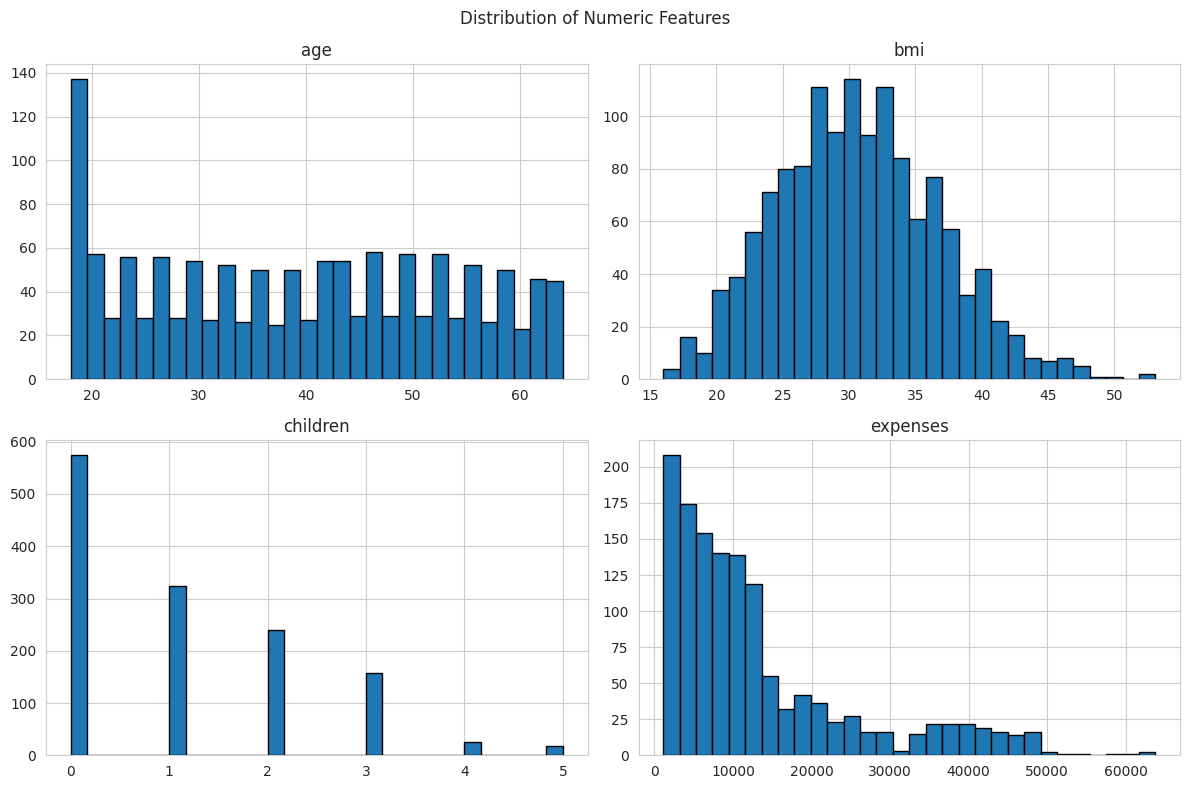

In [ ]:
numeric_cols = ["age", "bmi", "children", "expenses"]

df[numeric_cols].hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

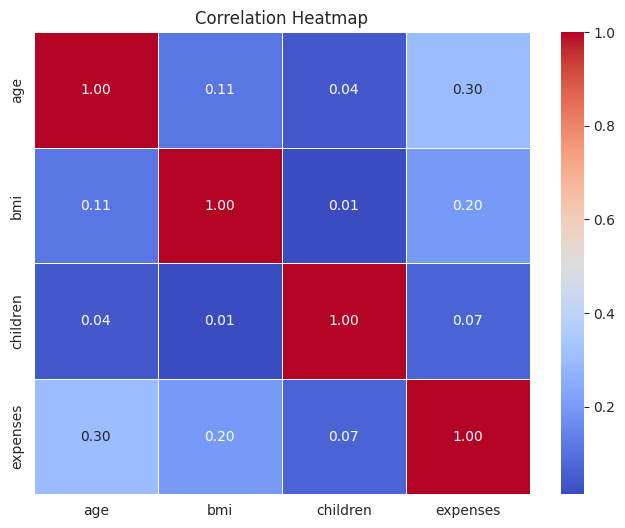

In [ ]:
# only numeric columns correlate directly
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

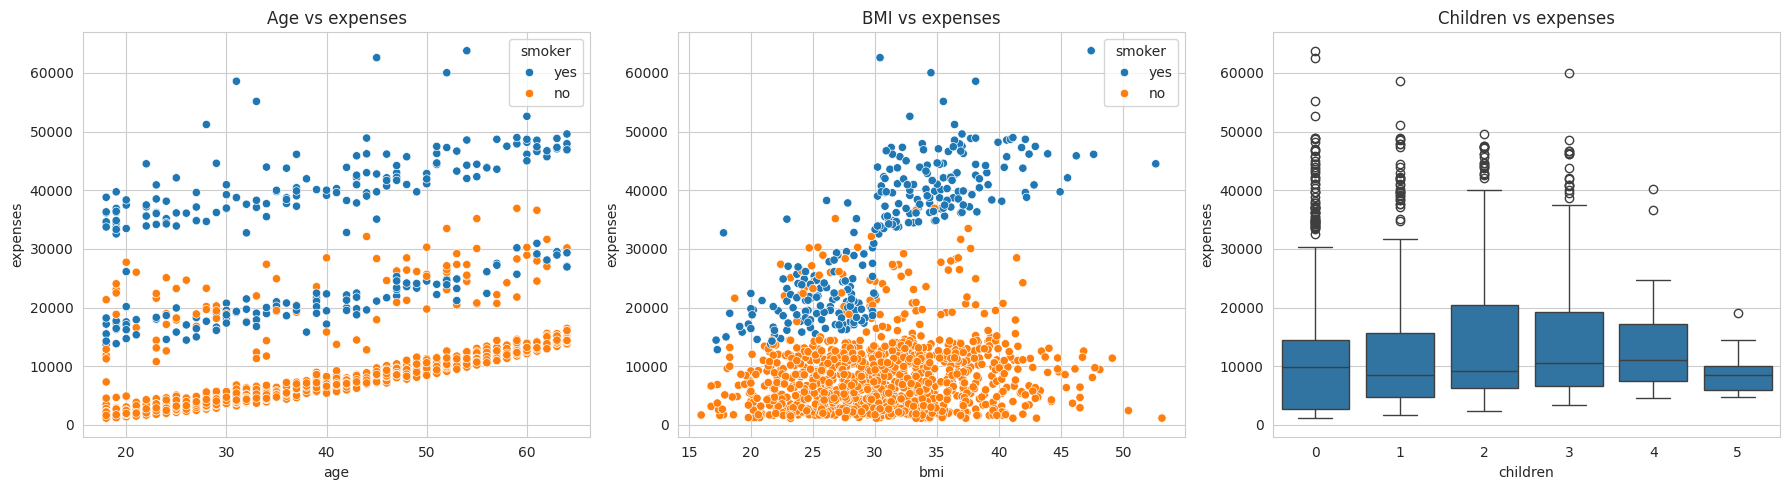

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="age", y="expenses", hue="smoker", ax=axes[0])
axes[0].set_title("Age vs expenses")

sns.scatterplot(data=df, x="bmi", y="expenses", hue="smoker", ax=axes[1])
axes[1].set_title("BMI vs expenses")

sns.boxplot(data=df, x="children", y="expenses", ax=axes[2])
axes[2].set_title("Children vs expenses")

plt.tight_layout()
plt.show()

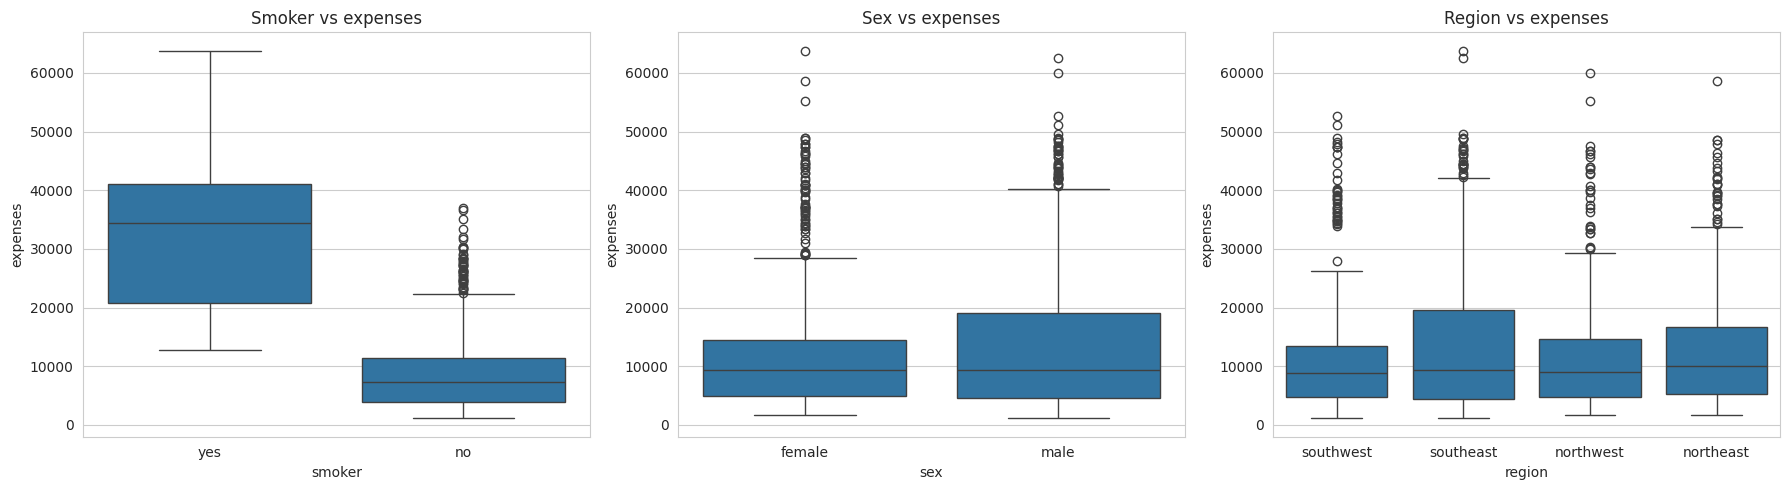

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="smoker", y="expenses", ax=axes[0])
axes[0].set_title("Smoker vs expenses")

sns.boxplot(data=df, x="sex", y="expenses", ax=axes[1])
axes[1].set_title("Sex vs expenses")

sns.boxplot(data=df, x="region", y="expenses", ax=axes[2])
axes[2].set_title("Region vs expenses")

plt.tight_layout()
plt.show()

#Part 3

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [ ]:
df["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
# Binary encoding for sex and smoker
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# One-hot encoding for region
df = pd.get_dummies(df, columns=['region'], drop_first=False)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,expenses,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.9,0,1,16884.92,False,False,False,True
1,18,0,33.8,1,0,1725.55,False,False,True,False
2,28,0,33.0,3,0,4449.46,False,False,True,False
3,33,0,22.7,0,0,21984.47,False,True,False,False
4,32,0,28.9,0,0,3866.86,False,True,False,False


In [ ]:
df.dtypes

,0
age,int64
sex,int64
bmi,float64
children,int64
smoker,int64
expenses,float64
region_northeast,bool
region_northwest,bool
region_southeast,bool
region_southwest,bool


In [ ]:
X = df[["age",'bmi','smoker','sex']]
y = df['expenses']

print("Features:", X)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features:       age   bmi  smoker  sex
0      19  27.9       1    1
1      18  33.8       0    0
2      28  33.0       0    0
3      33  22.7       0    0
4      32  28.9       0    0
...   ...   ...     ...  ...
1333   50  31.0       0    0
1334   18  31.9       0    1
1335   18  36.9       0    1
1336   21  25.8       0    1
1337   61  29.1       1    1

[1338 rows x 4 columns]
X shape: (1338, 4)
y shape: (1338,)


# part 4

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1070
Test size: 268


In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

# quick look at actual vs predicted
import pandas as pd
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
comparison.head(10)

,Actual,Predicted
0,9095.07,11801.606852
1,5272.18,6916.922153
2,29330.98,27503.008333
3,9301.89,11801.606852
4,33750.29,34232.778462
5,4536.26,6916.922153
6,2117.34,2004.606129
7,14210.54,16465.834242
8,3732.63,7057.662571
9,10264.44,11801.606852


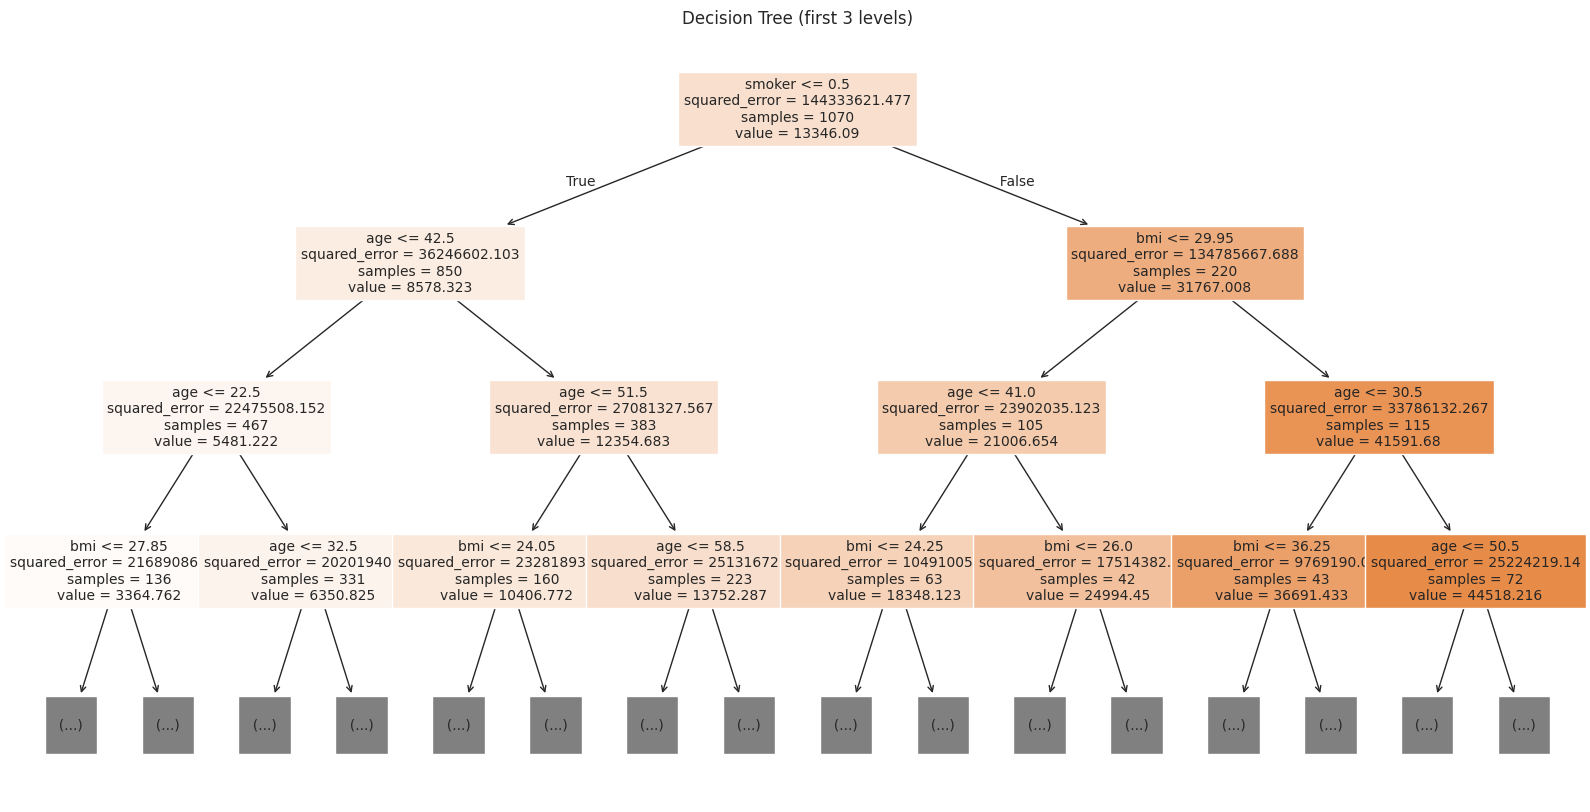

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, filled=True, max_depth=3, fontsize=10)
plt.title("Decision Tree (first 3 levels)")
plt.show()

# part 5

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  2679.28
MSE:  21090844.98
RMSE: 4592.48
R²:   0.8641


# More understaning

In [ ]:
for depth in [3, 4, 5, 6, 7, None]:
    m = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=10, random_state=42)
    m.fit(X_train, y_train)
    train_r2 = m.score(X_train, y_train)
    test_r2 = m.score(X_test, y_test)
    print(f"max_depth={depth}: Train R²={train_r2:.4f}, Test R²={test_r2:.4f}")

max_depth=3: Train R²=0.8537, Test R²=0.8531
max_depth=4: Train R²=0.8640, Test R²=0.8620
max_depth=5: Train R²=0.8690, Test R²=0.8641
max_depth=6: Train R²=0.8756, Test R²=0.8613
max_depth=7: Train R²=0.8801, Test R²=0.8574
max_depth=None: Train R²=0.8856, Test R²=0.8588


In [ ]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")

Train R²: 0.8690
Test R²:  0.8641


# Bonus Challenge

* Q1) Improve the model performance
* Q2) Compare their algorithm with another regression model
* Q3) Tune hyperparameters

In [ ]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_leaf': [5, 10, 15, 20],
    'min_samples_split': [10, 20, 30]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

best_model = grid_search.best_estimator_
print("Test R²:", best_model.score(X_test, y_test))

Best parameters: {'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best CV R²: 0.8417060003793562
Test R²: 0.8620491836294183


In [ ]:
y_pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)

print(f"Best Model — MAE: {mae_best:.2f}, MSE: {mse_best:.2f}, RMSE: {rmse_best:.2f}")

Best Model — MAE: 2719.64, MSE: 21416689.56, RMSE: 4627.82


# Decision Tree Regression vs Random Forest Regression

Decision Tree Regression: A single tree that splits the data into parts based on feature values. It makes predictions by following decision rules from the root to the leaf nodes. It is easy to understand and interpret, but it can overfit the training data.

Random Forest Regression: Uses multiple decision trees (ensemble) instead of a single tree. Each tree is trained on a random subset of the data, and the final prediction is the average of all trees. This approach reduces overfitting and usually provides better accuracy than a single Decision Tree.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

x = df.drop("expenses", axis=1)
y = df["expenses"]


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Single Decision Tree
DecisionTrees = model
print("Decision Tree MSE:", mean_squared_error(y_test, single_tree_pred))
print("Decision Tree RMSE:", mean_squared_error(y_test, single_tree_pred) ** 0.5)
print("Decision Tree R²:", r2_score(y_test, single_tree_pred))

# Random Forest
Randomforestm = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    max_features="sqrt",
    random_state=42
)
Randomforestm.fit(x_train, y_train)
many_trees_pred = Randomforestm.predict(x_test)
print("Random Forest MSE:", mean_squared_error(y_test, many_trees_pred))
print("Random Forest RMSE:", mean_squared_error(y_test, many_trees_pred) ** 0.5)
print("Random Forest R²:", r2_score(y_test, many_trees_pred))

y_pred = DecisionTrees.predict(x_test)

Decision Tree MSE: 22812670.316367526
Decision Tree RMSE: 4776.261123134656
Random Forest MSE: 37578706.73157131
Random Forest RMSE: 6130.14736621978
Decision Tree R²: 0.8530572857587291


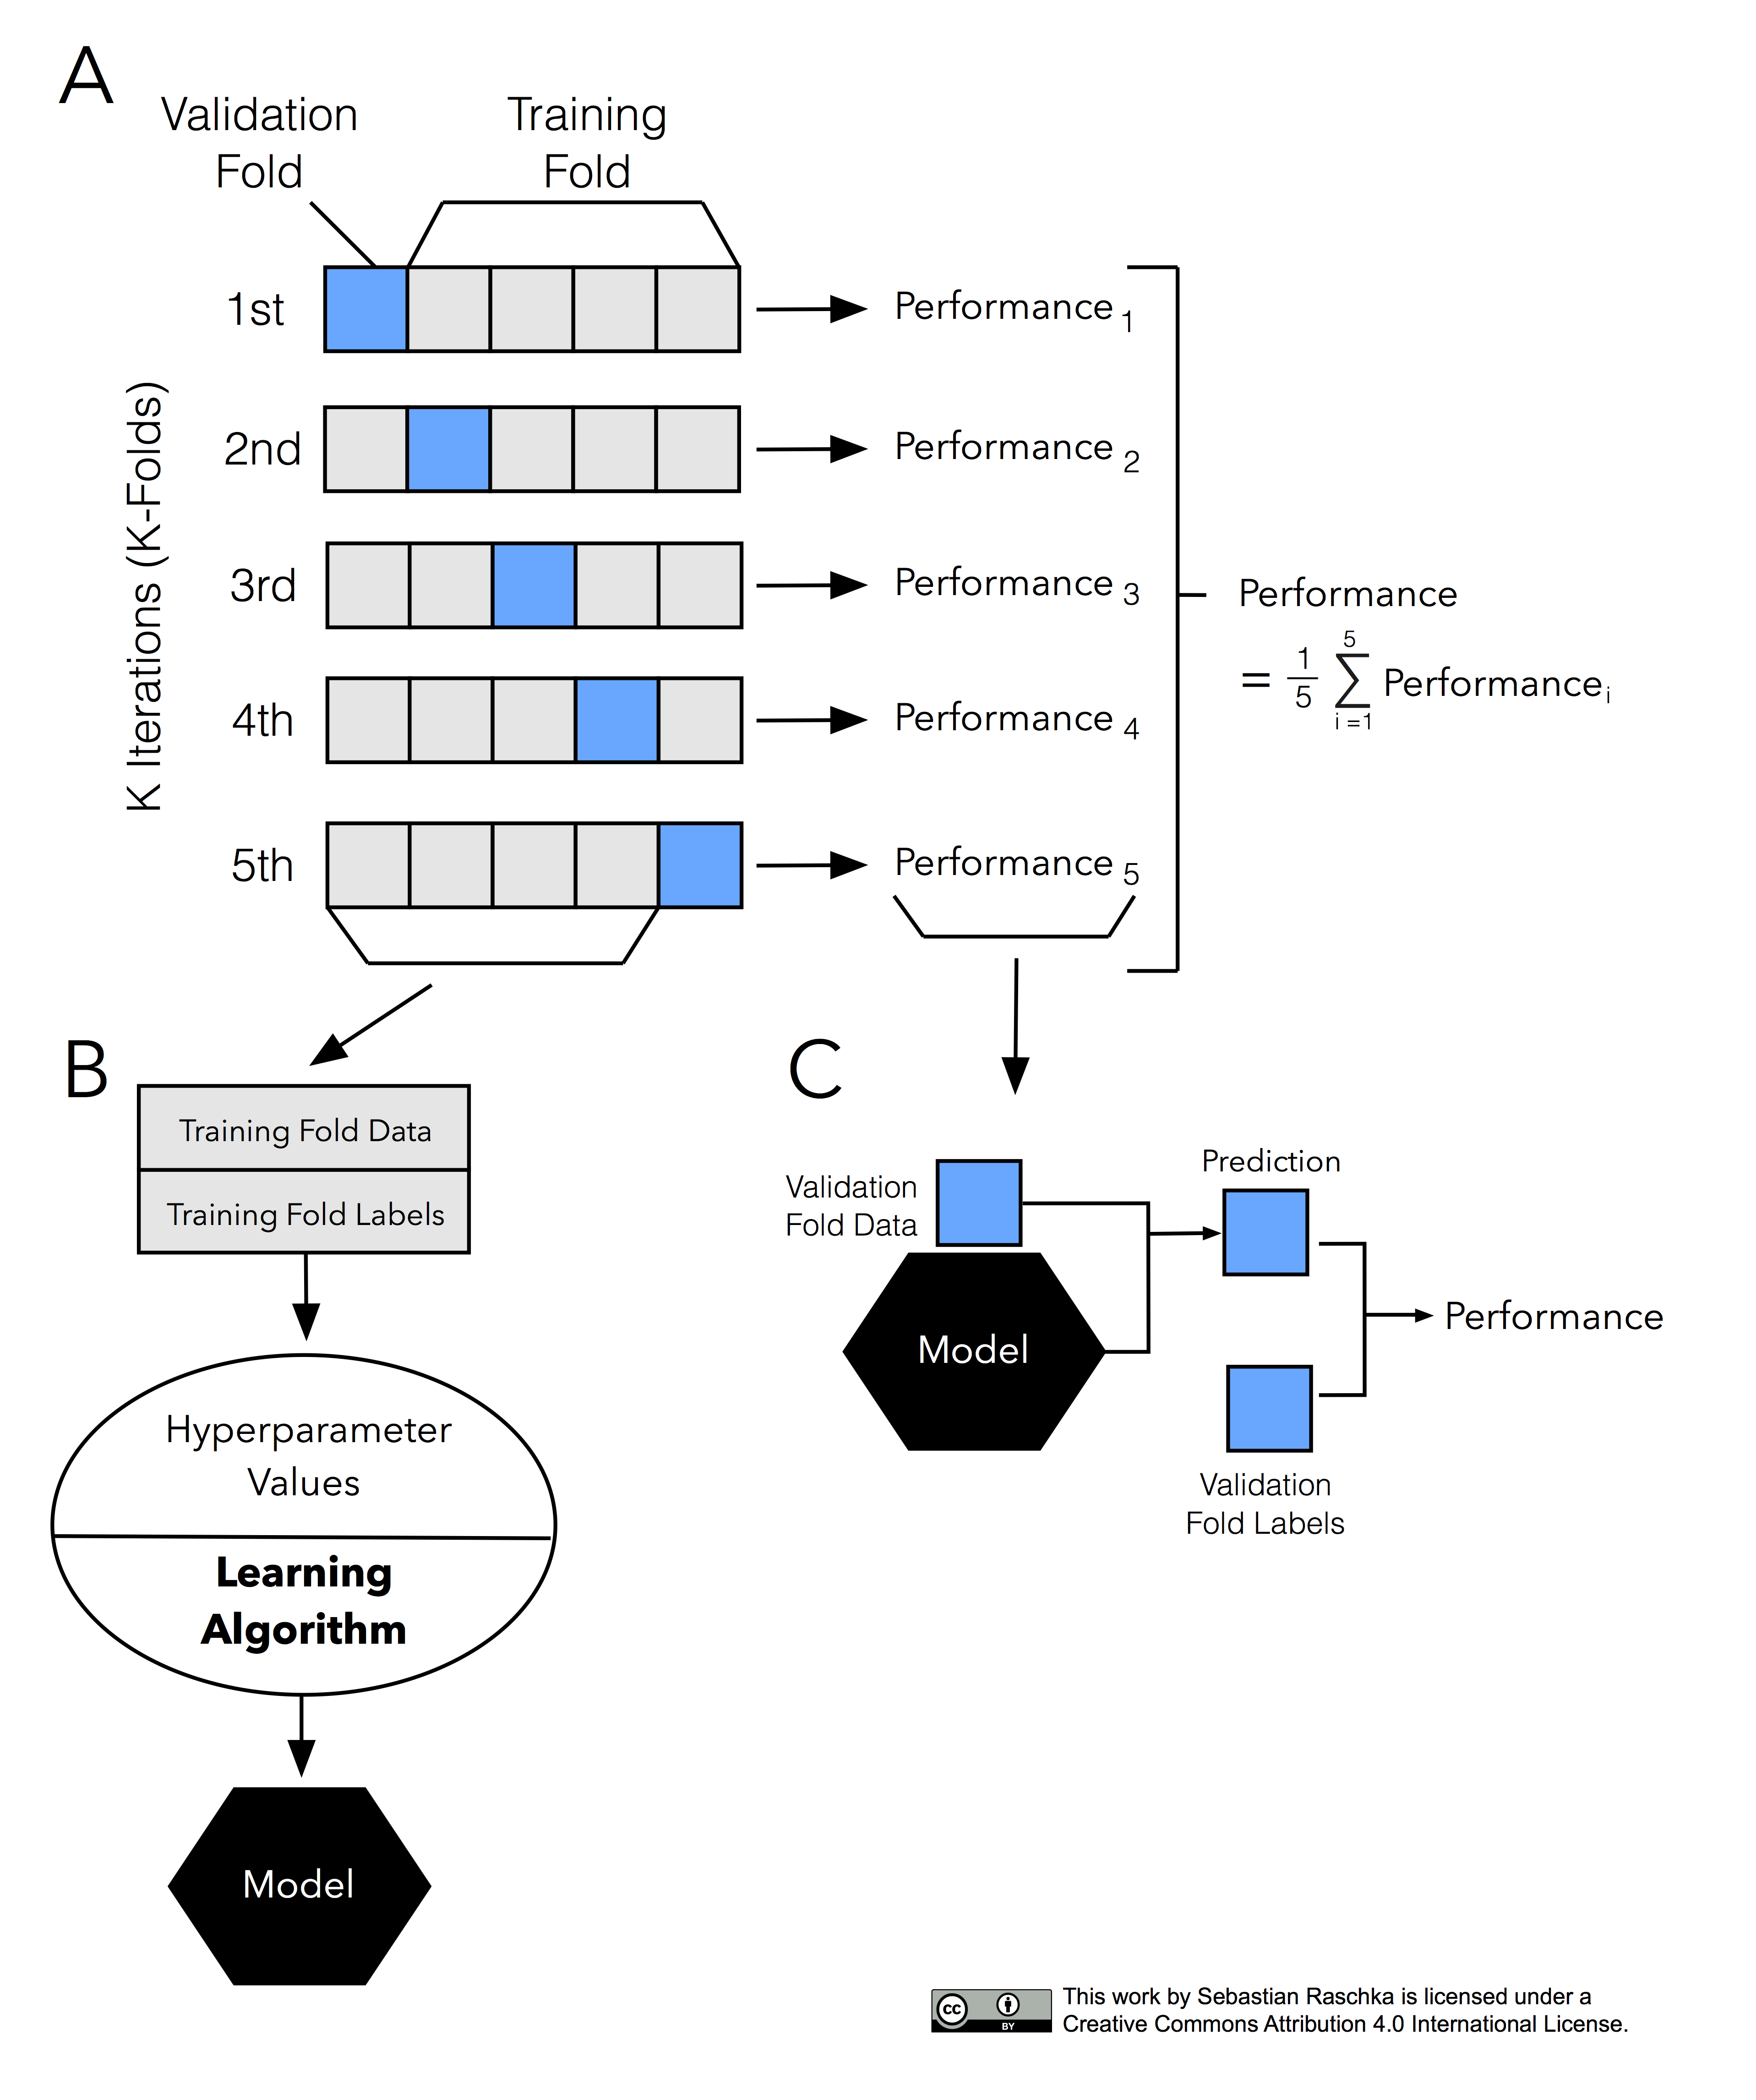